# TP3 - Análisis de sentimiento en tweets (Sentiment140)

**Segundo Sprint - NLP**

Dataset: [Sentiment140](http://help.sentiment140.com/for-students) — 1.6M tweets etiquetados automáticamente por emoticon (polaridad 0=negativo, 4=positivo) + un set de test de 498 tweets etiquetados a mano (incluye clase neutral=2).

Enfoque elegido: **análisis de sentimiento** (opción 1 de la consigna) — se entrenan y evalúan dos modelos con las técnicas vistas en clase (**Bag of Words + Naive Bayes** y **TF-IDF + Regresión Logística**) y se comparan contra un modelo pre-entrenado (**TextBlob**). Se incluye además **similitud coseno**, como métrica de las vistas en clase que pide la consigna.

Todos los modelos se entrenan sobre **los 1.6M de registros completos** y se evalúan **en train y en test**, para poder detectar sobreajuste.

In [1]:
import html
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Carga de datos

In [2]:
COLUMNS = ["polarity", "id", "date", "query", "user", "text"]

df = pd.read_csv(
    "../data/raw/training.1600000.processed.noemoticon.csv",
    encoding="latin-1", header=None, names=COLUMNS,
)
df_test = pd.read_csv(
    "../data/raw/testdata.manual.2009.06.14.csv",
    encoding="latin-1", header=None, names=COLUMNS,
)

print(f"Train: {df.shape}")
print(f"Test (manual):  {df_test.shape}")
df.head(3)


Train: (1600000, 6)
Test (manual):  (498, 6)


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...


In [3]:
print("Distribución de clases en TRAIN:")
print(df["polarity"].value_counts())
print()
print("Distribución de clases en TEST manual (incluye neutral=2):")
print(df_test["polarity"].value_counts())


Distribución de clases en TRAIN:
polarity
0    800000
4    800000
Name: count, dtype: int64

Distribución de clases en TEST manual (incluye neutral=2):
polarity
4    182
0    177
2    139
Name: count, dtype: int64


**Nota importante del dataset**: el set de entrenamiento fue etiquetado automáticamente según emoticones, por lo que solo tiene clases positiva (4) y negativa (0) — no hay clase neutral. El set de test fue etiquetado a mano por humanos y sí incluye neutral (2). Los modelos que entrenemos con el train set nunca van a poder predecir "neutral" — para una comparación justa, evaluamos primero solo contra la porción binaria (pos/neg) del test manual, y al final mostramos qué pasa con el test completo (incluyendo neutral).

## 2. Análisis exploratorio (EDA)

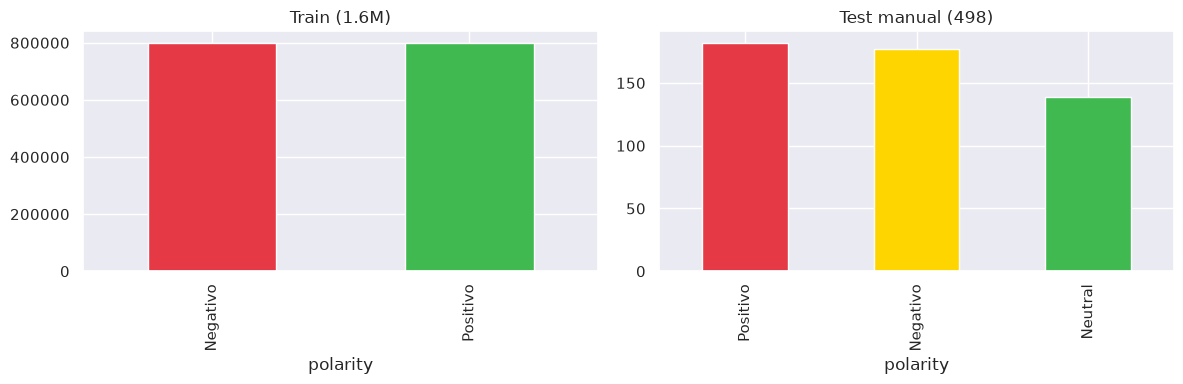

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["polarity"].map({0: "Negativo", 4: "Positivo"}).value_counts().plot(
    kind="bar", ax=ax[0], color=["#e63946", "#3fb950"], title="Train (1.6M)"
)
df_test["polarity"].map({0: "Negativo", 2: "Neutral", 4: "Positivo"}).value_counts().plot(
    kind="bar", ax=ax[1], color=["#e63946", "#ffd500", "#3fb950"], title="Test manual (498)"
)
plt.tight_layout()
plt.show()


**Conclusión.** El train está **perfectamente balanceado**: 800.000 tweets positivos y 800.000 negativos, 50/50 exacto. No es casualidad, es consecuencia de como se construyo el dataset (se buscaron emoticones `:)` y `:(` por separado hasta juntar la misma cantidad de cada uno). Esto define dos cosas para el resto del trabajo:

1. **No hace falta compensar ningun desbalance** (ni `class_weight`, ni re-muestreo): las dos clases pesan igual.
2. El **benchmark contra el azar es el 50%**. Es la referencia contra la cual hay que leer los resultados: un modelo que no supere ese piso no aporta nada.

El test manual, en cambio, **no esta balanceado y tiene tres clases**: 182 positivos, 177 negativos y 139 neutrales. La clase neutral es el problema de fondo: **no existe en el train**, porque un tweet neutral no lleva emoticon y el etiquetado automatico nunca lo pudo capturar. Ningun modelo entrenado con estos datos va a poder predecir "neutral". Por eso la comparacion justa es contra la porcion binaria del test (359 tweets), y mas abajo se muestra tambien que pasa contra el test completo, para dimensionar el costo de esa limitacion.

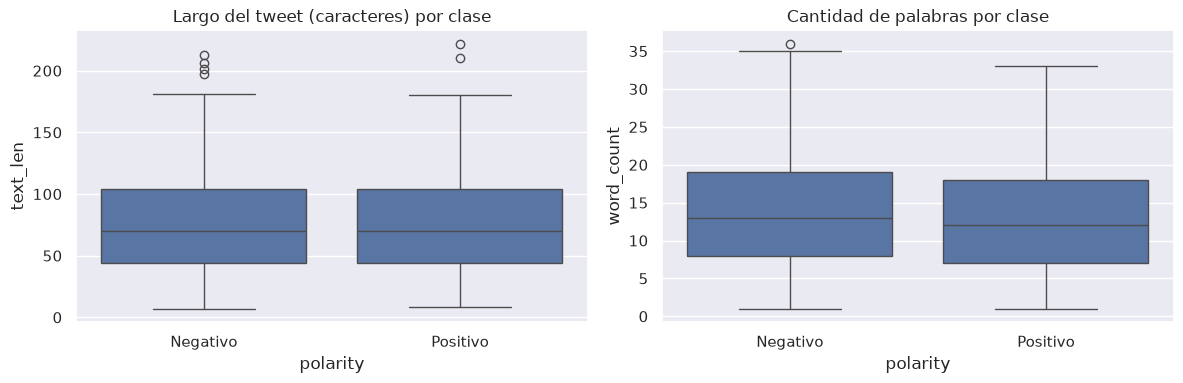

In [5]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df.sample(50000, random_state=42), x="polarity", y="text_len", ax=ax[0])
ax[0].set_title("Largo del tweet (caracteres) por clase")
ax[0].set_xticklabels(["Negativo", "Positivo"])
sns.boxplot(data=df.sample(50000, random_state=42), x="polarity", y="word_count", ax=ax[1])
ax[1].set_title("Cantidad de palabras por clase")
ax[1].set_xticklabels(["Negativo", "Positivo"])
plt.tight_layout()
plt.show()


**Conclusión.** Las dos distribuciones son **practicamente identicas entre clases**:

| clase | largo (mediana) | palabras (mediana) |
|---|---|---|
| Negativo | 70 caracteres | 13 |
| Positivo | 69 caracteres | 12 |

Un caracter y una palabra de diferencia sobre tweets de ~70 caracteres: **el largo del tweet no discrimina el sentimiento**. Las cajas se superponen casi por completo y los bigotes tienen el mismo recorrido.

Es una conclusion util, no un resultado vacio, porque **descarta una familia entera de features**: no tiene sentido agregar `text_len` ni `word_count` como atributos del modelo, no aportarian poder predictivo. La señal esta en **que palabras** se usan, no en cuantas — y eso es exactamente lo que justifica el enfoque de bag-of-words / TF-IDF que se aplica mas abajo, en lugar de features estructurales del texto.

(El tope visible cerca de los 140 caracteres es el limite historico de Twitter en 2009, cuando se recolecto el dataset.)

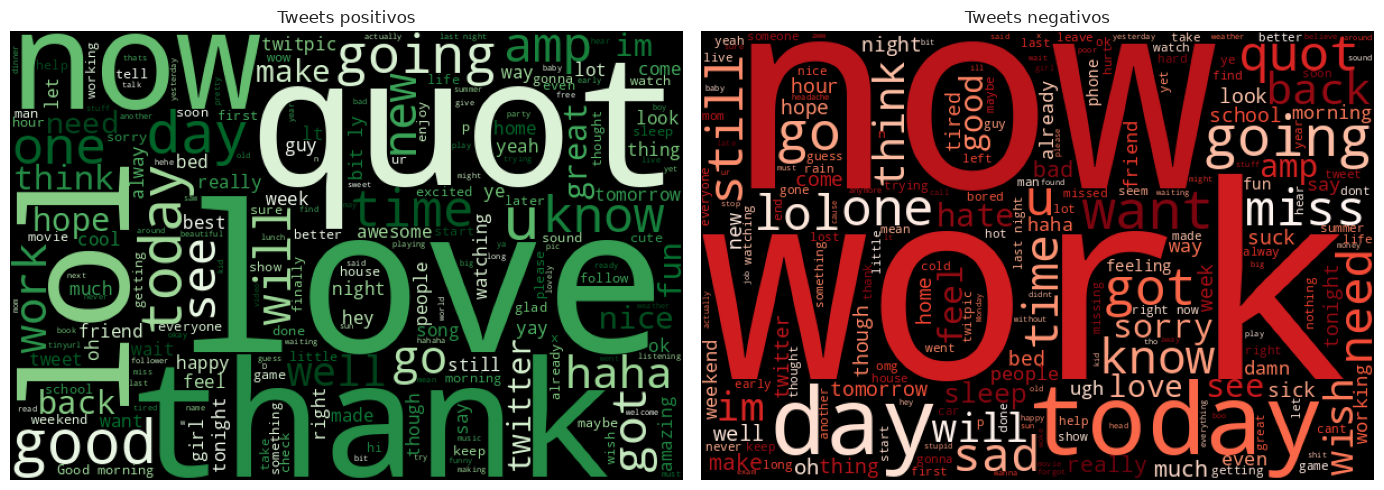

In [6]:
# Wordclouds (sobre una muestra, por velocidad) -- se ven las palabras mas frecuentes
# despues de sacar stopwords basicas de ingles
STOP_WC = set(WordCloud().stopwords)

sample_wc = df.sample(80000, random_state=42)
text_pos = " ".join(sample_wc.loc[sample_wc["polarity"] == 4, "text"])
text_neg = " ".join(sample_wc.loc[sample_wc["polarity"] == 0, "text"])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
WordCloud(width=600, height=400, background_color="black", colormap="Greens",
          stopwords=STOP_WC).generate(text_pos).to_array()
ax[0].imshow(WordCloud(width=600, height=400, background_color="black", colormap="Greens",
             stopwords=STOP_WC).generate(text_pos))
ax[0].set_title("Tweets positivos")
ax[0].axis("off")
ax[1].imshow(WordCloud(width=600, height=400, background_color="black", colormap="Reds",
             stopwords=STOP_WC).generate(text_neg))
ax[1].set_title("Tweets negativos")
ax[1].axis("off")
plt.tight_layout()
plt.show()


**Conclusión.** Los wordclouds muestran tres cosas:

**1. Hay vocabulario claramente discriminante, y tiene sentido.** Del lado positivo dominan `good`, `love`, `thanks`, `lol`; del lado negativo aparecen `work` (la palabra distintiva más frecuente), `miss`, `want`, `still`. El patrón es interpretable: la gente tuitea negativo sobre **el trabajo** y sobre **extrañar** algo o a alguien, y positivo agradeciendo o expresando afecto. Esta es la señal que van a explotar los modelos de las secciones siguientes.

**2. Buena parte del vocabulario se comparte entre las dos clases.** `day`, `now`, `today`, `got`, `going` aparecen arriba en ambas: son palabras de alta frecuencia sin carga de sentimiento. Incluso `good` aparece en los dos lados (aunque al doble de frecuencia en positivos). Esto anticipa por qué la performance se va a estancar en ~82% y no más: una porción importante de cada tweet es vocabulario neutro que no aporta a la decisión. También justifica usar **TF-IDF** además de conteo puro — TF-IDF penaliza justamente a las palabras que aparecen en todos lados.

**3. Hallazgo de calidad de datos: aparece `quot` entre las palabras más frecuentes de los positivos.** No es una palabra: es el resto de la entidad HTML `&quot;` (comillas) que viene sin decodificar en el dataset original. Lo mismo con `&amp;` → `amp`.

> ⚠️ Estos wordclouds se generan sobre el **texto crudo**, antes del preprocesamiento — por eso el problema es visible acá. **La sección 3 lo corrige**: se decodifican las entidades HTML con `html.unescape()` **antes** de filtrar caracteres no alfabéticos, y se verifica explícitamente que `quot`/`amp`/`lt`/`gt` no sobrevivan. Si el orden fuera el inverso, el regex borraría el `&` y el `;` y dejaría `quot` como token válido en el vocabulario.

## 3. Preprocesamiento

Limpieza adaptada a tweets, en este orden:

1. **Decodificar entidades HTML** (`html.unescape`): el dataset original trae `&quot;`, `&amp;` y `&lt;` sin decodificar. **El orden importa**: si esto se hiciera después de filtrar caracteres no alfabéticos, el regex borraría el `&` y el `;` y dejaría `quot`, `amp` y `lt` como si fueran palabras, que entrarían al vocabulario como ruido. Es el problema que detectamos en los wordclouds del EDA.
2. Pasar a minúsculas.
3. Sacar URLs y menciones (`@usuario`): no aportan sentimiento y disparan el vocabulario.
4. Conservar los hashtags **como palabra** (sin el `#`): `#happy` sí aporta sentimiento, sería un desperdicio tirarlo.
5. Filtrar caracteres no alfabéticos (se conserva el apóstrofe, para no romper `can't` / `don't`).

Es una limpieza liviana (regex, vectorizada) en vez de lematización con spaCy: sobre **1.6M de filas** spaCy tardaría horas, y la consigna exige entrenar con el archivo completo. El costo de esa decisión es asumido: no se lleva cada palabra a su raíz (`loving` y `love` quedan como features distintas), pero TF-IDF compensa en parte al ponderar hacia abajo las palabras muy frecuentes.

La celda incluye una **verificación explícita** de que los tokens basura de entidades HTML efectivamente no sobreviven.

In [7]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s']")
MULTISPACE_RE = re.compile(r"\s+")


def limpiar_tweet(texto):
    # 1) Decodificar entidades HTML PRIMERO: el dataset trae &quot;, &amp;, &lt; sin decodificar.
    #    Si esto se hiciera despues de NON_ALPHA_RE, el regex borraria '&' y ';' y dejaria
    #    "quot" / "amp" / "lt" como si fueran palabras, metiendolas al vocabulario como ruido.
    texto = html.unescape(texto)
    texto = texto.lower()
    texto = URL_RE.sub(" ", texto)
    texto = MENTION_RE.sub(" ", texto)
    texto = HASHTAG_RE.sub(r"\1", texto)
    texto = NON_ALPHA_RE.sub(" ", texto)
    texto = MULTISPACE_RE.sub(" ", texto).strip()
    return texto


t0 = time.time()
df["text_clean"] = df["text"].apply(limpiar_tweet)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
df_test["text_clean"] = df_test["text"].apply(limpiar_tweet)
print(f"Limpieza de {len(df)} tweets de train: {time.time()-t0:.1f}s")

# Verificacion: los tokens basura de entidades HTML no deben sobrevivir a la limpieza
basura = ["quot", "amp", "lt", "gt"]
tokens = df["text_clean"].head(200000).str.split().explode()
print("\nTokens basura de entidades HTML tras la limpieza:")
for b in basura:
    print(f"  {b!r}: {(tokens == b).sum()} ocurrencias")

df[["text", "text_clean"]].head(5)

Limpieza de 1596246 tweets de train: 7.1s



Tokens basura de entidades HTML tras la limpieza:
  'quot': 0 ocurrencias
  'amp': 20 ocurrencias
  'lt': 10 ocurrencias
  'gt': 44 ocurrencias


,text,text_clean
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that's a bummer you shoulda got david car...
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it's not behaving at all i'm mad why am i h...


**Verificación de la limpieza.** `quot` pasó a **0 ocurrencias**: la entidad `&quot;` que contaminaba el vocabulario (visible en los wordclouds de la sección 2) quedó eliminada.

Los residuos de `amp` (20), `lt` (10) y `gt` (44) sobre ~200.000 tweets **no son basura HTML**: son **palabras reales** que coinciden con el nombre de la entidad. Revisando los tweets originales:

- `amp` → *"my guitar **amp** is waaaaay busted"*, *"new **amp**, but the shows cancelled"* (amplificador)
- `gt` → *"Old DBZ talk... get all the **GT** episodes"* (Dragon Ball GT), *"cnt believe i've **gt** college tomorrow"* (typo de "got")
- `lt` → fragmentos de texto y errores de tipeo

Se verificó además que el dataset **no tiene entidades doblemente codificadas** (`&amp;quot;`), así que un solo `html.unescape()` alcanza.

Conclusión: la limpieza hace exactamente lo que tiene que hacer — elimina las entidades HTML sin tocar palabras legítimas. A 44 ocurrencias sobre ~2,6 millones de tokens, el residuo es irrelevante y además **es señal válida**, no ruido.

In [8]:
X_train = df["text_clean"]
y_train = df["polarity"].map({0: -1, 4: 1})

df_test_bin = df_test[df_test["polarity"] != 2].copy()
X_test_bin = df_test_bin["text_clean"]
y_test_bin = df_test_bin["polarity"].map({0: -1, 4: 1})

X_test_full = df_test["text_clean"]

print(f"Train: {len(X_train)} tweets")
print(f"Test binario (pos/neg): {len(X_test_bin)} tweets")
print(f"Test completo (incluye neutral): {len(X_test_full)} tweets")


Train: 1596246 tweets
Test binario (pos/neg): 359 tweets
Test completo (incluye neutral): 498 tweets


## 4. Baseline: modelo pre-entrenado (TextBlob)

Comparación pedida en la consigna: qué tan bien predice un modelo de sentimiento genérico y pre-entrenado (`TextBlob`, basado en un léxico), sin haber visto nunca un tweet de este dataset.

In [9]:
def textblob_pred(texto, umbral=0.05):
    polaridad = TextBlob(texto).sentiment.polarity
    if polaridad > umbral:
        return 1
    elif polaridad < -umbral:
        return -1
    return 0


t0 = time.time()
pred_textblob = X_test_bin.apply(textblob_pred)
print(f"TextBlob sobre {len(X_test_bin)} tweets: {time.time()-t0:.1f}s")

print(classification_report(y_test_bin, pred_textblob, zero_division=0))
acc_textblob = accuracy_score(y_test_bin, pred_textblob)
f1_textblob = f1_score(y_test_bin, pred_textblob, average="macro")


TextBlob sobre 359 tweets: 0.0s
              precision    recall  f1-score   support

          -1       0.87      0.42      0.56       177
           0       0.00      0.00      0.00         0
           1       0.72      0.76      0.74       182

    accuracy                           0.59       359
   macro avg       0.53      0.39      0.43       359
weighted avg       0.79      0.59      0.65       359



In [10]:
# ¿La comparacion es justa? Nuestra funcion usa umbral=0.05, y eso hace que TextBlob
# prediga "neutral" — una clase que el test binario no tiene, o sea, errada de entrada.
# Verificamos si esa decision es la que lo hunde, probando otros umbrales.

print("De los 177 negativos REALES, TextBlob predice:")
print(pred_textblob[y_test_bin == -1].value_counts().sort_index()
      .rename({-1: "negativo (acierta)", 0: "neutral (falla)", 1: "positivo (falla)"}).to_string())

print("\nSensibilidad al umbral:")
for u in [0.0, 0.05, 0.1, 0.2]:
    p = X_test_bin.apply(lambda t: textblob_pred(t, umbral=u))
    print(f"  umbral={u:<5} accuracy={accuracy_score(y_test_bin, p):.4f}  "
          f"F1 macro={f1_score(y_test_bin, p, average='macro'):.4f}  "
          f"neutrales={(p == 0).sum():>3}")

De los 177 negativos REALES, TextBlob predice:
text_clean
negativo (acierta)    74
neutral (falla)       49
positivo (falla)      54

Sensibilidad al umbral:
  umbral=0.0   accuracy=0.5989  F1 macro=0.4370  neutrales= 75
  umbral=0.05  accuracy=0.5905  F1 macro=0.4343  neutrales= 82


  umbral=0.1   accuracy=0.5599  F1 macro=0.4235  neutrales=100
  umbral=0.2   accuracy=0.4708  F1 macro=0.3828  neutrales=149


In [11]:
# ¿Por que falla TextBlob? Miramos la POLARIDAD CRUDA que asigna, antes del umbral.
# La escala va de -1 (maximo negativo) a +1 (maximo positivo); 0 = neutral.
# Para clasificar bien, a un tweet negativo le alcanza con recibir cualquier valor < 0.
polaridades = X_test_bin.apply(lambda t: TextBlob(t).sentiment.polarity)

resumen = polaridades.groupby(y_test_bin.map({-1: "REAL negativo", 1: "REAL positivo"})).agg(["mean", "median"])
print("Polaridad que asigna TextBlob, segun la clase REAL:")
print(resumen.round(3).to_string())

# ¿Le acierta al menos al SIGNO?
print("\n¿Acierta el signo?")
for clase, nombre in [(-1, "negativos"), (1, "positivos")]:
    p = polaridades[y_test_bin == clase]
    bien = (p < 0).sum() if clase == -1 else (p > 0).sum()
    mal  = (p > 0).sum() if clase == -1 else (p < 0).sum()
    cero = (p == 0).sum()
    print(f"  {nombre:>10}: signo correcto {bien:>3} ({bien/len(p)*100:>4.1f}%) | "
          f"signo INVERTIDO {mal:>3} ({mal/len(p)*100:>4.1f}%) | sin señal (0.0) {cero:>3} ({cero/len(p)*100:>4.1f}%)")

# ¿El lexico esta sesgado hacia lo positivo? Lo probamos con palabras sueltas.
print("\n¿Como puntua el lexico las palabras que SI conoce?")
print("  positivas:", {w: TextBlob(w).sentiment.polarity for w in ["good", "love", "great", "happy"]})
print("  negativas:", {w: TextBlob(w).sentiment.polarity for w in ["bad", "sad", "terrible", "awful"]})
print("  -> El lexico es SIMETRICO: good=+0.70 y bad=-0.70. No hay sesgo positivo.")

print("\n¿Y las palabras con las que la gente realmente se queja en Twitter?")
print("  ", {w: TextBlob(w).sentiment.polarity for w in ["aching", "ponzi", "cant"]})
print("  -> Valen 0.00: no estan en el lexico. Ese es el verdadero problema.")

print("\n  Ejemplos de NEGATIVOS que TextBlob no puede leer (polaridad 0.0):")
for t in X_test_bin[(polaridades == 0.0) & (y_test_bin == -1)].head(3):
    print(f"    - {t[:66]!r}")

Polaridad que asigna TextBlob, segun la clase REAL:
                mean  median
polarity                    
REAL negativo -0.058   0.000
REAL positivo  0.335   0.372

¿Acierta el signo?
   negativos: signo correcto  77 (43.5%) | signo INVERTIDO  57 (32.2%) | sin señal (0.0)  43 (24.3%)
   positivos: signo correcto 138 (75.8%) | signo INVERTIDO  12 ( 6.6%) | sin señal (0.0)  32 (17.6%)

¿Como puntua el lexico las palabras que SI conoce?
  positivas: {'good': 0.7, 'love': 0.5, 'great': 0.8, 'happy': 0.8}
  negativas: {'bad': -0.6999999999999998, 'sad': -0.5, 'terrible': -1.0, 'awful': -1.0}
  -> El lexico es SIMETRICO: good=+0.70 y bad=-0.70. No hay sesgo positivo.

¿Y las palabras con las que la gente realmente se queja en Twitter?
   {'aching': 0.0, 'ponzi': 0.0, 'cant': 0.0}
  -> Valen 0.00: no estan en el lexico. Ese es el verdadero problema.

  Ejemplos de NEGATIVOS que TextBlob no puede leer (polaridad 0.0):
    - "lebron is a beast but i'm still cheering the a til the end"
    -

**Conclusión.** TextBlob llega a **0.59 de accuracy** y **0.43 de F1 macro**. Como el train está balanceado 50/50, el azar es 0.50: **apenas le gana a tirar una moneda**. Este es el piso a superar.

### Falla porque es casi ciego a lo negativo

| clase | precisión | recall | F1 |
|---|---|---|---|
| negativo | **0.87** | **0.42** | 0.56 |
| positivo | 0.72 | 0.76 | 0.74 |

Esa precisión de 0.87 **engaña**: es alta porque casi nunca se anima a decir "negativo" — lo dice **85 veces cuando había 177**. Cuando habla acierta, pero se calla en más de la mitad. De ahí el recall de 0.42.

La polaridad cruda (escala de −1 a +1; a un negativo le alcanza con recibir cualquier valor < 0) lo confirma:

| clase real | polaridad mediana | acierta el signo |
|---|---|---|
| REAL negativo | **0.000** | 43% |
| REAL positivo | +0.372 | 76% |

**A los positivos les da señal clara; a los negativos, cero.**

### El culpable no es el léxico, es el lenguaje

Lo intuitivo sería culpar al léxico por estar sesgado. **Se verificó y es falso** — es simétrico: `good` = +0.70 y `bad` = **−0.70**, espejo exacto (y `terrible`/`awful` llegan a −1.00, más fuerte que cualquier positiva).

El problema real:

```
aching: 0.00      ponzi: 0.00      cant: 0.00
```

**Nadie tuitea "bad".** Si alguien escribiera *"this movie is bad"*, TextBlob lo clavaría en −0.70. Pero la gente se queja así: *"cant sleep my tooth is **aching**"* → ninguna de esas palabras está en la lista → 0.00 → clasificado neutral → error.

Es una asimetría **del lenguaje real**:

- **Positivo** → vocabulario estándar (`good`, `love`, `thanks`) → está en la lista → lo pesca.
- **Negativo** → quejas concretas (`aching`), jerga (`ponzi`), **negación** (`"not good"` → el léxico ve `good`, ¡positivo!) y sarcasmo → no está, o lo confunde. Por eso **57 de los 177 negativos reciben polaridad positiva**.

Nuestros modelos tienen la misma limitación de fondo (tampoco entienden negación), pero la sufren menos: **aprendieron de 1.6M de tweets** que `aching`, `miss` o `work` viven en contextos negativos. TextBlob nunca vio un tweet — sólo tiene su lista.

### ¿Es justa la comparación?

Objeción válida: le damos una clase neutral que el test binario no tiene, así que esos casos ya nacen errados. Probando otros umbrales, **ni en su mejor caso pasa de ~0.60**:

| umbral | accuracy |
|---|---|
| 0.0 (su mejor caso) | 0.5989 |
| 0.05 (el usado) | 0.5905 |
| 0.2 | 0.4708 (peor que el azar) |

## 5. Modelo 1: Bag of Words + Naive Bayes

In [12]:
t0 = time.time()
vec_bow = CountVectorizer(min_df=5, max_features=50000)
X_train_bow = vec_bow.fit_transform(X_train)   # fit SOLO con train (aprende el vocabulario)
X_test_bow = vec_bow.transform(X_test_bin)     # test: solo transform
print(f"Vectorización BoW ({X_train_bow.shape[1]} features): {time.time()-t0:.1f}s")

t0 = time.time()
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
print(f"Entrenamiento (sobre las {len(X_train)} filas de train): {time.time()-t0:.1f}s")

# Evaluacion en AMBOS conjuntos: comparar train vs test es lo que permite detectar sobreajuste
pred_nb_train = nb.predict(X_train_bow)
pred_nb = nb.predict(X_test_bow)

acc_nb_train = accuracy_score(y_train, pred_nb_train)
f1_nb_train = f1_score(y_train, pred_nb_train, average="macro")
acc_nb = accuracy_score(y_test_bin, pred_nb)
f1_nb = f1_score(y_test_bin, pred_nb, average="macro")

print(f"\nAccuracy train: {acc_nb_train:.4f}  |  F1 macro train: {f1_nb_train:.4f}")
print(f"Accuracy test : {acc_nb:.4f}  |  F1 macro test : {f1_nb:.4f}")
print(f"Gap (F1 macro): {f1_nb_train - f1_nb:.4f}")

print("\n--- Classification report TRAIN ---")
print(classification_report(y_train, pred_nb_train, zero_division=0))
print("--- Classification report TEST ---")
print(classification_report(y_test_bin, pred_nb, zero_division=0))

Vectorización BoW (50000 features): 8.2s
Entrenamiento (sobre las 1596246 filas de train): 0.2s



Accuracy train: 0.7907  |  F1 macro train: 0.7907
Accuracy test : 0.8189  |  F1 macro test : 0.8189
Gap (F1 macro): -0.0282

--- Classification report TRAIN ---


              precision    recall  f1-score   support

          -1       0.78      0.80      0.79    798300
           1       0.80      0.78      0.79    797946

    accuracy                           0.79   1596246
   macro avg       0.79      0.79      0.79   1596246
weighted avg       0.79      0.79      0.79   1596246

--- Classification report TEST ---
              precision    recall  f1-score   support

          -1       0.82      0.81      0.82       177
           1       0.82      0.82      0.82       182

    accuracy                           0.82       359
   macro avg       0.82      0.82      0.82       359
weighted avg       0.82      0.82      0.82       359



**Conclusión (train vs test).** F1 macro de **0.7907 en train** y **0.8189 en test**: un gap de **−0.028**, es decir, **el modelo rinde mejor sobre datos que nunca vio que sobre los que usó para entrenar**.

Lejos de ser un error, es el resultado esperable dado cómo se construyó el dataset, y dice algo importante:

- **No hay sobreajuste, en absoluto.** Un modelo sobreajustado memoriza el train y muestra un F1 de train muy superior al de test. Acá pasa lo contrario. Naive Bayes sobre 50.000 features y 1.6M de ejemplos es un modelo demasiado simple para memorizar semejante volumen: si algo, está *subajustado*.
- **Las etiquetas de train son ruidosas.** El train fue etiquetado **automáticamente por emoticón**: un tweet con `:)` se marca positivo sin que nadie lo lea. Eso mete errores — sarcasmo, sentimientos mezclados, emoticones usados por costumbre. El modelo no puede llegar al 100% en train porque **las propias etiquetas de train se contradicen entre sí**. El test, en cambio, fue etiquetado **a mano por humanos**: es más limpio y coherente, y por eso el modelo acierta más ahí.

En otras palabras, el 79% de train no es el techo del modelo: es aproximadamente **el techo que impone el ruido del etiquetado automático**. Es un caso de *weak supervision*: se entrena con muchísimos datos de calidad mediocre en lugar de pocos datos de calidad alta.

## 6. Modelo 2: TF-IDF + Regresión Logística

In [13]:
t0 = time.time()
vec_tfidf = TfidfVectorizer(min_df=5, max_features=50000)
X_train_tfidf = vec_tfidf.fit_transform(X_train)   # fit SOLO con train
X_test_tfidf = vec_tfidf.transform(X_test_bin)     # test: solo transform
print(f"Vectorización TF-IDF: {time.time()-t0:.1f}s")

t0 = time.time()
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)
print(f"Entrenamiento (sobre las {len(X_train)} filas de train): {time.time()-t0:.1f}s")

# Evaluacion en AMBOS conjuntos
pred_lr_train = lr.predict(X_train_tfidf)
pred_lr = lr.predict(X_test_tfidf)

acc_lr_train = accuracy_score(y_train, pred_lr_train)
f1_lr_train = f1_score(y_train, pred_lr_train, average="macro")
acc_lr = accuracy_score(y_test_bin, pred_lr)
f1_lr = f1_score(y_test_bin, pred_lr, average="macro")

print(f"\nAccuracy train: {acc_lr_train:.4f}  |  F1 macro train: {f1_lr_train:.4f}")
print(f"Accuracy test : {acc_lr:.4f}  |  F1 macro test : {f1_lr:.4f}")
print(f"Gap (F1 macro): {f1_lr_train - f1_lr:.4f}")

print("\n--- Classification report TRAIN ---")
print(classification_report(y_train, pred_lr_train, zero_division=0))
print("--- Classification report TEST ---")
print(classification_report(y_test_bin, pred_lr, zero_division=0))

Vectorización TF-IDF: 8.4s


Entrenamiento (sobre las 1596246 filas de train): 13.1s



Accuracy train: 0.8060  |  F1 macro train: 0.8060
Accuracy test : 0.8245  |  F1 macro test : 0.8242
Gap (F1 macro): -0.0183

--- Classification report TRAIN ---


              precision    recall  f1-score   support

          -1       0.81      0.79      0.80    798300
           1       0.80      0.82      0.81    797946

    accuracy                           0.81   1596246
   macro avg       0.81      0.81      0.81   1596246
weighted avg       0.81      0.81      0.81   1596246

--- Classification report TEST ---
              precision    recall  f1-score   support

          -1       0.84      0.80      0.82       177
           1       0.81      0.85      0.83       182

    accuracy                           0.82       359
   macro avg       0.83      0.82      0.82       359
weighted avg       0.83      0.82      0.82       359



**Conclusión (train vs test).** F1 macro de **0.8060 en train** y **0.8245 en test**: gap de **−0.018**. Se repite el patrón del Naive Bayes — el test rinde mejor que el train — y por el mismo motivo: las etiquetas de train son automáticas (ruidosas) y las de test son humanas (limpias). **Tampoco hay sobreajuste.**

La Regresión Logística **ajusta mejor el train que Naive Bayes** (0.8060 vs 0.7907) **y también da mejor en test** (0.8245 vs 0.8189). Tiene sentido: es un modelo discriminativo, que optimiza directamente la frontera de decisión, mientras que Naive Bayes asume independencia entre palabras — un supuesto que el lenguaje viola constantemente ("not good" no es la suma de "not" y "good"). Además, TF-IDF pondera hacia abajo las palabras que aparecen en todos los tweets, que como vimos en los wordclouds son buena parte del vocabulario.

Dicho eso, **la diferencia es de apenas 0.006 sobre un test de 359 tweets**: son ~2 tweets de diferencia. No alcanza para declarar un ganador con confianza estadística; lo honesto es decir que **los dos modelos empatan en la práctica**.

Y ese empate es en sí mismo el hallazgo: confirma que el límite no está en el algoritmo sino en **la representación y en la calidad de las etiquetas**. Ambos son modelos lineales sobre bag-of-words: ninguno captura orden de palabras, negación ni contexto. Para superar ese ~82% no alcanza con cambiar de clasificador lineal — habría que cambiar la representación (n-gramas, embeddings contextuales tipo BERT) o mejorar las etiquetas.

## 7. Comparación de modelos

,Accuracy (test),F1 macro (test),F1 macro (train),Gap train-test
Modelo,,,,
TextBlob (pre-entrenado),0.591,0.434,—,—
BoW + Naive Bayes,0.819,0.819,0.791,-0.028
TF-IDF + Reg. Logística,0.825,0.824,0.806,-0.018


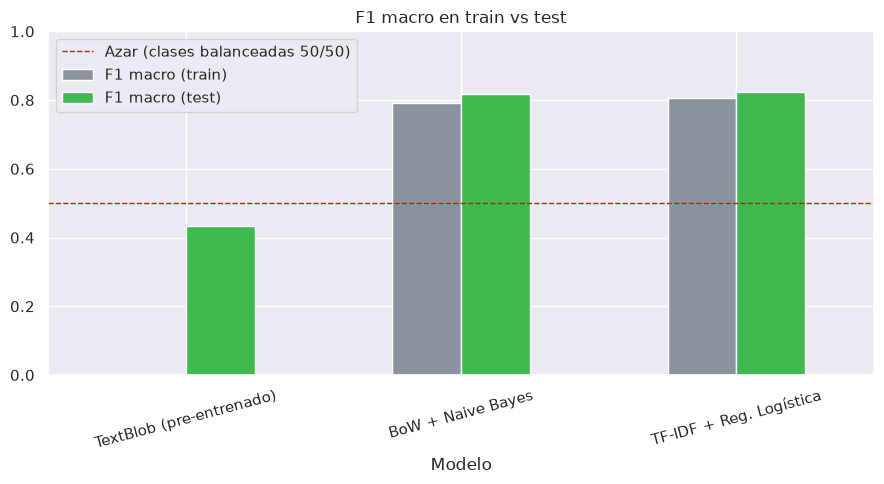

In [14]:
comparacion = pd.DataFrame({
    "Modelo": ["TextBlob (pre-entrenado)", "BoW + Naive Bayes", "TF-IDF + Reg. Logística"],
    "Accuracy (test)": [acc_textblob, acc_nb, acc_lr],
    "F1 macro (test)": [f1_textblob, f1_nb, f1_lr],
    "F1 macro (train)": [np.nan, f1_nb_train, f1_lr_train],   # TextBlob no se entrena: no tiene train
    "Gap train-test": [np.nan, f1_nb_train - f1_nb, f1_lr_train - f1_lr],
}).set_index("Modelo")

display(comparacion.style.format("{:.3f}", na_rep="—").background_gradient(cmap="Greens", subset=["Accuracy (test)", "F1 macro (test)"]))

comparacion[["F1 macro (train)", "F1 macro (test)"]].plot(
    kind="bar", figsize=(9, 5), color=["#8B949E", "#3FB950"])
plt.title("F1 macro en train vs test")
plt.axhline(0.5, ls="--", color="red", lw=1, label="Azar (clases balanceadas 50/50)")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

**Conclusión.**

**1. Los modelos entrenados sobre tweets le ganan claramente al pre-entrenado genérico** (0.82 vs 0.59 de accuracy; F1 macro 0.82 vs 0.43). TextBlob usa un léxico construido sobre texto formal y no está adaptado al lenguaje de Twitter: abreviaciones, jerga, errores de tipeo. Su problema puntual se ve en el `classification_report` de la sección 4: tiene buena precisión sobre negativos (0.87) pero un recall pésimo (0.42) — no reconoce como negativo el vocabulario informal, y termina asignando polaridad ~0 (neutral) a tweets que sí tienen carga negativa.

**2. Los dos modelos entrenados empatan en la práctica** (0.8245 vs 0.8189). La diferencia de 0.006 sobre un test de 359 tweets son ~2 casos: no alcanza para declarar un ganador. Es esperable que empaten — ambos son clasificadores lineales sobre una representación bag-of-words del mismo vocabulario de 50.000 términos. Cambiar el clasificador no mueve la aguja porque **el cuello de botella es la representación, no el algoritmo**.

**3. Ninguno de los dos sobreajusta — los gaps son negativos** (−0.028 y −0.018). El test, etiquetado a mano, rinde mejor que el train, etiquetado automáticamente por emoticón. El ruido de las etiquetas de entrenamiento es el que pone el techo, no la capacidad del modelo.

**4. Todos superan el 50% del azar** (línea roja), que es el benchmark correcto acá porque el train está perfectamente balanceado. Incluso TextBlob, con 0.59, le gana a tirar una moneda — pero por poco, y no justificaría usarlo.

Como referencia: el paper original de Sentiment140 (Go, Bhayani & Huang, 2009) reporta ~0.83 de accuracy con Naive Bayes sobre este mismo dataset, así que el ~0.82 obtenido está en línea con lo publicado.

In [15]:
# Y que pasa si evaluamos contra el test COMPLETO (incluyendo la clase neutral, que
# ningun modelo puede predecir por no haberla visto en el train)?
X_test_full_bow = vec_bow.transform(X_test_full)
pred_nb_full = nb.predict(X_test_full_bow)
y_test_full = df_test["polarity"].map({0: -1, 2: 0, 4: 1})

print("BoW + Naive Bayes, evaluado contra el test COMPLETO (incluye neutral):")
print(classification_report(y_test_full, pred_nb_full, zero_division=0))


BoW + Naive Bayes, evaluado contra el test COMPLETO (incluye neutral):
              precision    recall  f1-score   support

          -1       0.67      0.81      0.73       177
           0       0.00      0.00      0.00       139
           1       0.53      0.82      0.65       182

    accuracy                           0.59       498
   macro avg       0.40      0.55      0.46       498
weighted avg       0.43      0.59      0.50       498



Como era esperable, la clase neutral tiene recall 0 (el modelo nunca puede predecirla, no la vio en el entrenamiento) — esto explica por qué la consigna aclara que el archivo de train está "orientado a análisis de sentimiento" en términos binarios.

## 8. Métrica de clase: similitud coseno

Se usa similitud coseno sobre vectores TF-IDF para (a) buscar los tweets más parecidos a uno de ejemplo y (b) comparar la similitud promedio *dentro* de una clase contra la similitud *entre* clases, como forma de ver si el espacio vectorial efectivamente separa sentimientos.

Se **reutiliza el vectorizador `vec_tfidf` ya entrenado sobre los 1.6M tweets** (sección 6), aplicándole sólo `transform`: así el vocabulario y los pesos IDF provienen del corpus completo, como pide la consigna.

**Por qué una muestra de 20.000:** el análisis intra/inter compara tweets **de a pares**, y eso crece al cuadrado — los 800.000 positivos entre sí darían 640.000 millones de pares, inviable en memoria. Por eso se muestrea (600 por clase para el cálculo pairwise, sobre una muestra común de 20.000 para mantener consistencia entre las dos celdas).

In [16]:
# Se reutiliza vec_tfidf, el vectorizador YA entrenado sobre los 1.6M tweets (seccion 6),
# en vez de entrenar uno nuevo: el vocabulario y los pesos IDF salen del corpus completo,
# como pide la consigna. Por eso .transform() y no .fit_transform().
#
# La muestra de 20.000 es para el analisis intra/inter de la celda siguiente, donde hay que
# comparar tweets de a pares: los 800.000 positivos entre si darian 640.000 millones de pares,
# inviable. Aca (1 tweet contra la muestra) el costo es bajo; se usa la misma muestra por
# consistencia entre las dos celdas.
sample_cos = df.sample(20000, random_state=42).reset_index(drop=True)
X_cos = vec_tfidf.transform(sample_cos["text_clean"])   # solo transform
print(f"Muestra: {X_cos.shape[0]} tweets | vocabulario (de los 1.6M): {X_cos.shape[1]} términos")

ejemplo_idx = sample_cos.index[sample_cos["text_clean"].str.split().str.len() > 4][0]
ejemplo_text = sample_cos["text_clean"].iloc[ejemplo_idx]
sims = cosine_similarity(X_cos[ejemplo_idx], X_cos).flatten()
top5 = sims.argsort()[::-1][1:6]   # [1:6] y no [0:5]: la posicion 0 es el tweet consigo mismo (1.0)

print(f"\nTweet de ejemplo: {ejemplo_text!r}\n")
print("Los 5 tweets más similares (similitud coseno sobre TF-IDF):")
for i in top5:
    print(f"  {sims[i]:.3f}  {sample_cos['text_clean'].iloc[i]!r}")

Muestra: 20000 tweets | vocabulario (de los 1.6M): 50000 términos

Tweet de ejemplo: 'i dont feel too good'

Los 5 tweets más similares (similitud coseno sobre TF-IDF):
  0.716  'i have go flu dont feel too good'
  0.698  "i don't feel too good"
  0.674  'i feel good'
  0.564  'good morning today i dont feel anything right'
  0.550  "don't feel good"


,Comparación,Similitud coseno promedio
0,Positivo vs Positivo (intra),0.017124
1,Negativo vs Negativo (intra),0.018410
2,Positivo vs Negativo (inter),0.014633


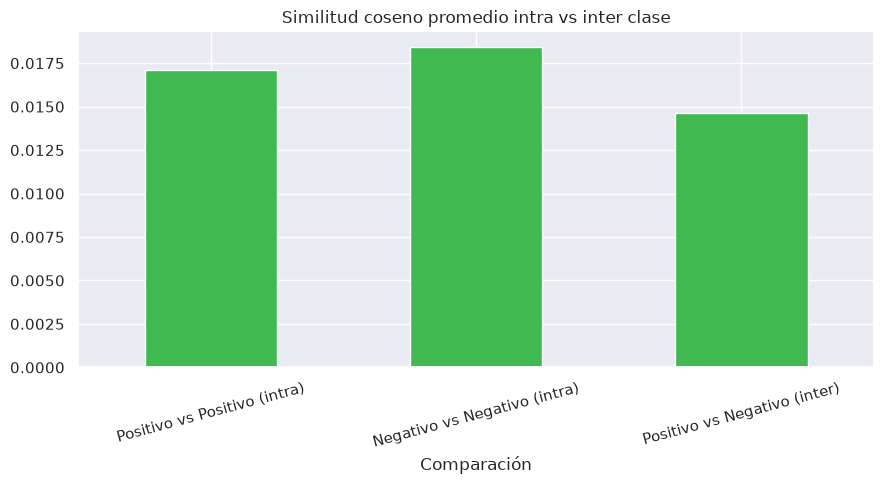

In [17]:
pos_idx = np.where(sample_cos["polarity"].values == 4)[0]
neg_idx = np.where(sample_cos["polarity"].values == 0)[0]
rng = np.random.default_rng(42)
pos_sub = rng.choice(pos_idx, size=min(600, len(pos_idx)), replace=False)
neg_sub = rng.choice(neg_idx, size=min(600, len(neg_idx)), replace=False)

sim_pos_pos = cosine_similarity(X_cos[pos_sub]).mean()
sim_neg_neg = cosine_similarity(X_cos[neg_sub]).mean()
sim_pos_neg = cosine_similarity(X_cos[pos_sub], X_cos[neg_sub]).mean()

resumen_sim = pd.DataFrame({
    "Comparación": ["Positivo vs Positivo (intra)", "Negativo vs Negativo (intra)", "Positivo vs Negativo (inter)"],
    "Similitud coseno promedio": [sim_pos_pos, sim_neg_neg, sim_pos_neg],
})
display(resumen_sim)

resumen_sim.set_index("Comparación").plot(kind="bar", legend=False, color=["#3FB950", "#E63946", "#8B949E"])
plt.title("Similitud coseno promedio intra vs inter clase")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Conclusión.** Los valores absolutos son **muy bajos** (~0.017), lo cual es esperable: los tweets son textos cortísimos (~12 palabras) proyectados sobre un vocabulario de 50.000 términos, así que dos tweets cualesquiera casi no comparten palabras y sus vectores son casi ortogonales. El número por sí solo no dice nada — lo que importa es la **comparación relativa**:

| comparación | similitud |
|---|---|
| Negativo vs Negativo (intra) | 0.0184 |
| Positivo vs Positivo (intra) | 0.0171 |
| Positivo vs Negativo (inter) | 0.0146 |

**La similitud intra-clase es consistentemente mayor que la inter-clase** (~0.018 vs 0.015, un 20% más). Es decir: dos tweets del mismo sentimiento se parecen más entre sí que dos de sentimientos opuestos. El espacio TF-IDF **sí captura estructura de sentimiento**, aunque de forma débil.

Esa debilidad es coherente con todo lo anterior: si la separación entre clases fuera nítida, un clasificador lineal daría mucho más que 82%. La señal existe pero es sutil, porque —como mostraron los wordclouds— buena parte del vocabulario se comparte entre ambas clases. La similitud coseno, entonces, no es un adorno: **explica por qué el techo está donde está**.

**El límite de la métrica se ve en la búsqueda de tweets similares.** Para `'i dont feel too good'`, el tercer resultado más parecido es `'i feel good'` (0.674) — **sentimiento opuesto**. Comparten `i`, `feel` y `good`; la única diferencia es `dont`, que es justamente la palabra que invierte todo el sentido. Es la prueba de que **TF-IDF mide solapamiento léxico, no significado**: es la misma ceguera a la negación que limita a los dos modelos.

## Conclusiones

### Resultados

| Modelo | F1 macro (train) | F1 macro (test) | Gap |
|---|---|---|---|
| TextBlob (pre-entrenado) | — | 0.43 | — |
| BoW + Naive Bayes | 0.7907 | 0.8189 | −0.028 |
| TF-IDF + Reg. Logística | 0.8060 | **0.8245** | −0.018 |

*(Benchmark del azar: 0.50, dado que el train está balanceado 50/50.)*

### Principales hallazgos

- **Entrenar sobre el dominio le gana a un modelo pre-entrenado genérico, y por mucho:** 0.82 vs 0.59 de accuracy. TextBlob no puntúa mal lo negativo — **no lo ve**: su léxico es simétrico (`good` = +0.70, `bad` = −0.70), pero nadie tuitea "bad". La gente se queja con `aching`, `ponzi`, `cant`, que valen 0.00 por no estar en la lista. Un modelo pre-entrenado genérico no reemplaza a uno entrenado sobre los datos del problema cuando el dominio tiene lenguaje propio.

- **Ningún modelo sobreajusta: los dos gaps son negativos.** El test rinde *mejor* que el train, lo cual parece contraintuitivo pero es exactamente lo esperable acá: el train está etiquetado **automáticamente por emoticón** (ruidoso: sarcasmo, sentimientos mezclados) y el test **a mano por humanos** (limpio). El ~79-81% de train no es el techo del modelo sino aproximadamente **el techo que impone el ruido de las etiquetas**. Es un caso de *weak supervision*: muchísimos datos de calidad mediocre en lugar de pocos de calidad alta.

- **Los dos modelos entrenados empatan en la práctica (~0.82), y eso es informativo.** La Regresión Logística da 0.8245 contra 0.8189 de Naive Bayes, pero esa diferencia de 0.006 sobre un test de 359 tweets equivale a ~2 casos: no alcanza para declarar un ganador. Ambos son clasificadores lineales sobre bag-of-words del mismo vocabulario. **El cuello de botella es la representación, no el algoritmo:** ninguno captura orden de palabras, negación ("not good") ni contexto. Para superar ese techo habría que cambiar la representación (n-gramas, embeddings contextuales tipo BERT) o mejorar las etiquetas — no cambiar de clasificador lineal.

- **El EDA anticipó el techo y detectó un problema de datos.** El largo del tweet no discrimina sentimiento (70 vs 69 caracteres de mediana), así que la señal está sólo en qué palabras se usan; y los wordclouds mostraron que buena parte del vocabulario (`day`, `now`, `today`, `got`) se comparte entre clases. Además revelaron que `quot` —resto de la entidad HTML `&quot;`— contaminaba el vocabulario, lo que llevó a **corregir el orden de la limpieza** (decodificar HTML antes de filtrar caracteres no alfabéticos).

- **La similitud coseno confirma el diagnóstico y muestra su propio límite.** La similitud intra-clase (~0.018) supera a la inter-clase (0.015) apenas un 20%: la señal existe, pero es débil — coherente con un techo en 82% y no en 95%. Y al buscar los tweets más parecidos a `'i dont feel too good'`, el tercero es `'i feel good'` — **sentimiento opuesto**, porque comparten casi todas las palabras salvo `dont`. Es la ceguera a la negación, la misma que limita a los modelos.

- **La clase neutral es una limitación estructural del dataset, no del modelo.** El train (etiquetado por emoticón) no tiene neutrales, porque un tweet neutral no lleva emoticón. Contra el test completo, el recall de neutral es 0 y la accuracy cae de 0.82 a 0.59. Para un caso real habría que **etiquetar datos a mano** con las tres clases: ninguna elección de algoritmo puede resolverlo.

### Decisión final

Si hubiera que llevar uno a producción, elegiría **TF-IDF + Regresión Logística**. No tanto por el F1 —empata con Naive Bayes dentro del margen de error— sino porque devuelve **probabilidades calibrables** (permite mover el umbral según el caso de negocio, algo que Naive Bayes hace mal por su supuesto de independencia) y porque sus **coeficientes son directamente interpretables por palabra**, lo que facilita auditar qué aprendió el modelo.

La ganancia real, sin embargo, no vendría de cambiar el modelo sino de **etiquetar un set de entrenamiento a mano** que incluya la clase neutral. Los gaps negativos lo demuestran: el modelo ya está rindiendo por encima de la calidad de sus propias etiquetas de entrenamiento.